# Single Patient Journey — Sepsis vs Normal

Comparing **one real ICU patient who developed sepsis** vs **one who did not**.

This is their actual recorded clinical data, hour by hour.

## Step 1: Find a Sepsis Patient & a Normal Patient

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load just enough rows to find patient IDs quickly
df_peek = pd.read_csv('combined_sepsis_data.csv', low_memory=False, nrows=50000)

# Group by patient, check if they ever got SepsisLabel=1
pat_summary = df_peek.groupby('Patient_ID').agg(
    max_label=('SepsisLabel', 'max'),
    n_hours=('SepsisLabel', 'count')
).reset_index()

sepsis_pats = pat_summary[pat_summary['max_label'] == 1].head(20)
normal_pats = pat_summary[pat_summary['max_label'] == 0].head(20)

print("First few SEPSIS patients:")
print(sepsis_pats[['Patient_ID', 'n_hours']].to_string(index=False))
print()
print("First few NORMAL patients:")
print(normal_pats[['Patient_ID', 'n_hours']].to_string(index=False))

First few SEPSIS patients:
Patient_ID  n_hours
   p000009      258
   p000011       34
   p000015       15
   p000018      134
   p000022       19
   p000028       31
   p000034       13
   p000042       73
   p000053       25
   p000056        9
   p000058        8
   p000063       14
   p000064       28
   p000078      104
   p000141       61
   p000161       23
   p000171       69
   p000178       97
   p000185       65
   p000188       84

First few NORMAL patients:
Patient_ID  n_hours
   p000001       54
   p000002       23
   p000003       48
   p000004       29
   p000005       48
   p000006       17
   p000007       45
   p000008       40
   p000010       23
   p000012       21
   p000013       39
   p000014       42
   p000016       19
   p000017       37
   p000019       48
   p000020       19
   p000021       57
   p000023       21
   p000024       51
   p000025       50


## Step 2: Pick One of Each and Load Their Full Data

> **Change `SEPSIS_PID` and `NORMAL_PID` below** to whichever IDs look good from the list above.
> Pick one with a decent number of hours (>20) for a good graph.

In [4]:
# ── CHANGE THESE to IDs from the list above ─────────────────────────────
SEPSIS_PID = sepsis_pats.iloc[0]['Patient_ID']   # change index if needed
NORMAL_PID = normal_pats.iloc[0]['Patient_ID']   # change index if needed
# ──────────────────────────────────────────────────────────────────────────

print(f"Selected SEPSIS patient : {SEPSIS_PID}")
print(f"Selected NORMAL patient : {NORMAL_PID}")

# Load full CSV, filter only these two patients
df_full = pd.read_csv('combined_sepsis_data.csv', low_memory=False)

pt_sep = df_full[df_full['Patient_ID'] == SEPSIS_PID].copy().reset_index(drop=True)
pt_nor = df_full[df_full['Patient_ID'] == NORMAL_PID].copy().reset_index(drop=True)

# Make SepsisLabel numeric (may be stored as float/string)
pt_sep['SepsisLabel'] = pd.to_numeric(pt_sep['SepsisLabel'], errors='coerce').fillna(0).astype(int)
pt_nor['SepsisLabel'] = pd.to_numeric(pt_nor['SepsisLabel'], errors='coerce').fillna(0).astype(int)

pt_sep['hour'] = range(len(pt_sep))
pt_nor['hour'] = range(len(pt_nor))

print(f"Sepsis patient rows      : {len(pt_sep)}")
print(f"Normal patient rows      : {len(pt_nor)}")
print(f"Sepsis label values      : {pt_sep['SepsisLabel'].value_counts().to_dict()}")

# Find onset hour safely
onset_rows = pt_sep[pt_sep['SepsisLabel'] == 1]
if len(onset_rows) == 0:
    print("WARNING: No SepsisLabel=1 found for this patient in full dataset!")
    print("Try a different SEPSIS_PID from the list above.")
    sepsis_onset = len(pt_sep) // 2   # fallback
else:
    sepsis_onset = onset_rows['hour'].iloc[0]
    print(f"Sepsis onset at hour     : {sepsis_onset}")

Selected SEPSIS patient : p000009
Selected NORMAL patient : p000001
Sepsis patient rows      : 516
Normal patient rows      : 108
Sepsis label values      : {0: 496, 1: 20}
Sepsis onset at hour     : 248


## Plot 1: Vital Signs Hour-by-Hour

Red dashed line = sepsis onset. Green shading = normal patient's stay.

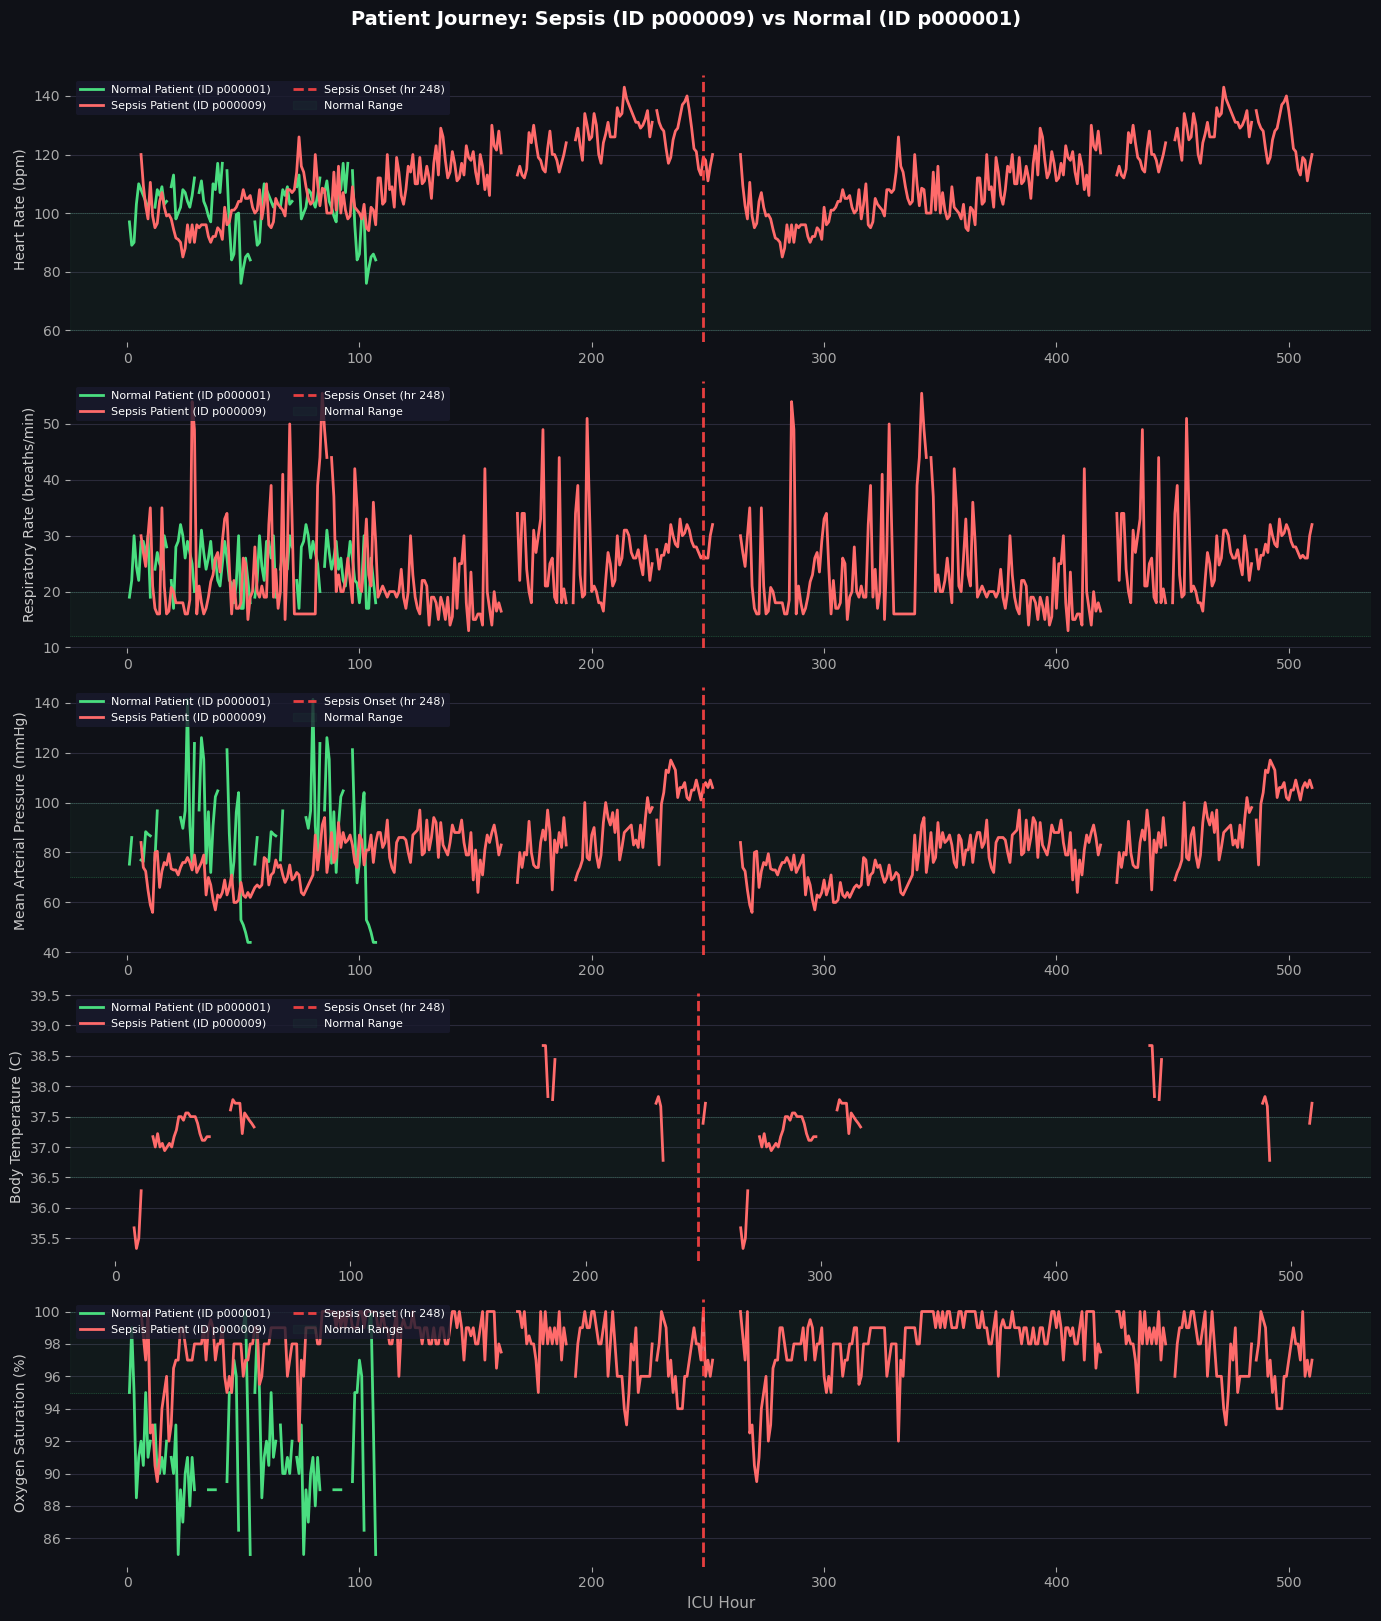

In [5]:
vitals = ['HR', 'Resp', 'MAP', 'Temp', 'O2Sat']
vital_labels = {
    'HR':    'Heart Rate (bpm)',
    'Resp':  'Respiratory Rate (breaths/min)',
    'MAP':   'Mean Arterial Pressure (mmHg)',
    'Temp':  'Body Temperature (C)',
    'O2Sat': 'Oxygen Saturation (%)',
}
# Normal ranges for reference lines
normal_ranges = {
    'HR':    (60, 100),
    'Resp':  (12, 20),
    'MAP':   (70, 100),
    'Temp':  (36.5, 37.5),
    'O2Sat': (95, 100),
}

for v in vitals:
    pt_sep[v] = pd.to_numeric(pt_sep[v], errors='coerce')
    pt_nor[v] = pd.to_numeric(pt_nor[v], errors='coerce')

fig, axes = plt.subplots(len(vitals), 1, figsize=(14, 16))
fig.patch.set_facecolor('#0F1117')
fig.suptitle(f'Patient Journey: Sepsis (ID {SEPSIS_PID}) vs Normal (ID {NORMAL_PID})',
             color='white', fontsize=14, fontweight='bold', y=1.01)

for ax, v in zip(axes, vitals):
    ax.set_facecolor('#0F1117')

    # Normal patient line
    ax.plot(pt_nor['hour'], pt_nor[v], color='#4ADE80', lw=2,
            label=f'Normal Patient (ID {NORMAL_PID})', zorder=3)

    # Sepsis patient line
    ax.plot(pt_sep['hour'], pt_sep[v], color='#FF6B6B', lw=2,
            label=f'Sepsis Patient (ID {SEPSIS_PID})', zorder=3)

    # Sepsis onset
    ax.axvline(sepsis_onset, color='#FF4444', lw=2, ls='--',
               alpha=0.9, label=f'Sepsis Onset (hr {sepsis_onset})', zorder=4)

    # Shaded normal range
    lo, hi = normal_ranges[v]
    ax.axhspan(lo, hi, color='#4ADE80', alpha=0.04, zorder=1, label='Normal Range')
    ax.axhline(lo, color='#4ADE80', lw=0.5, ls=':', alpha=0.4)
    ax.axhline(hi, color='#4ADE80', lw=0.5, ls=':', alpha=0.4)

    ax.set_ylabel(vital_labels[v], color='#CCCCCC', fontsize=10)
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.yaxis.grid(True, color='#2A2A3A', lw=0.8)
    ax.set_axisbelow(True)
    ax.legend(facecolor='#1A1A2E', edgecolor='none', labelcolor='white',
              fontsize=8, loc='upper left', ncol=2)

axes[-1].set_xlabel('ICU Hour', color='#AAAAAA', fontsize=11)
plt.tight_layout()
plt.show()

## Plot 2: Lab Values Over Time

Lab values are only measured sometimes (hence the gaps). Note how they change near sepsis onset.

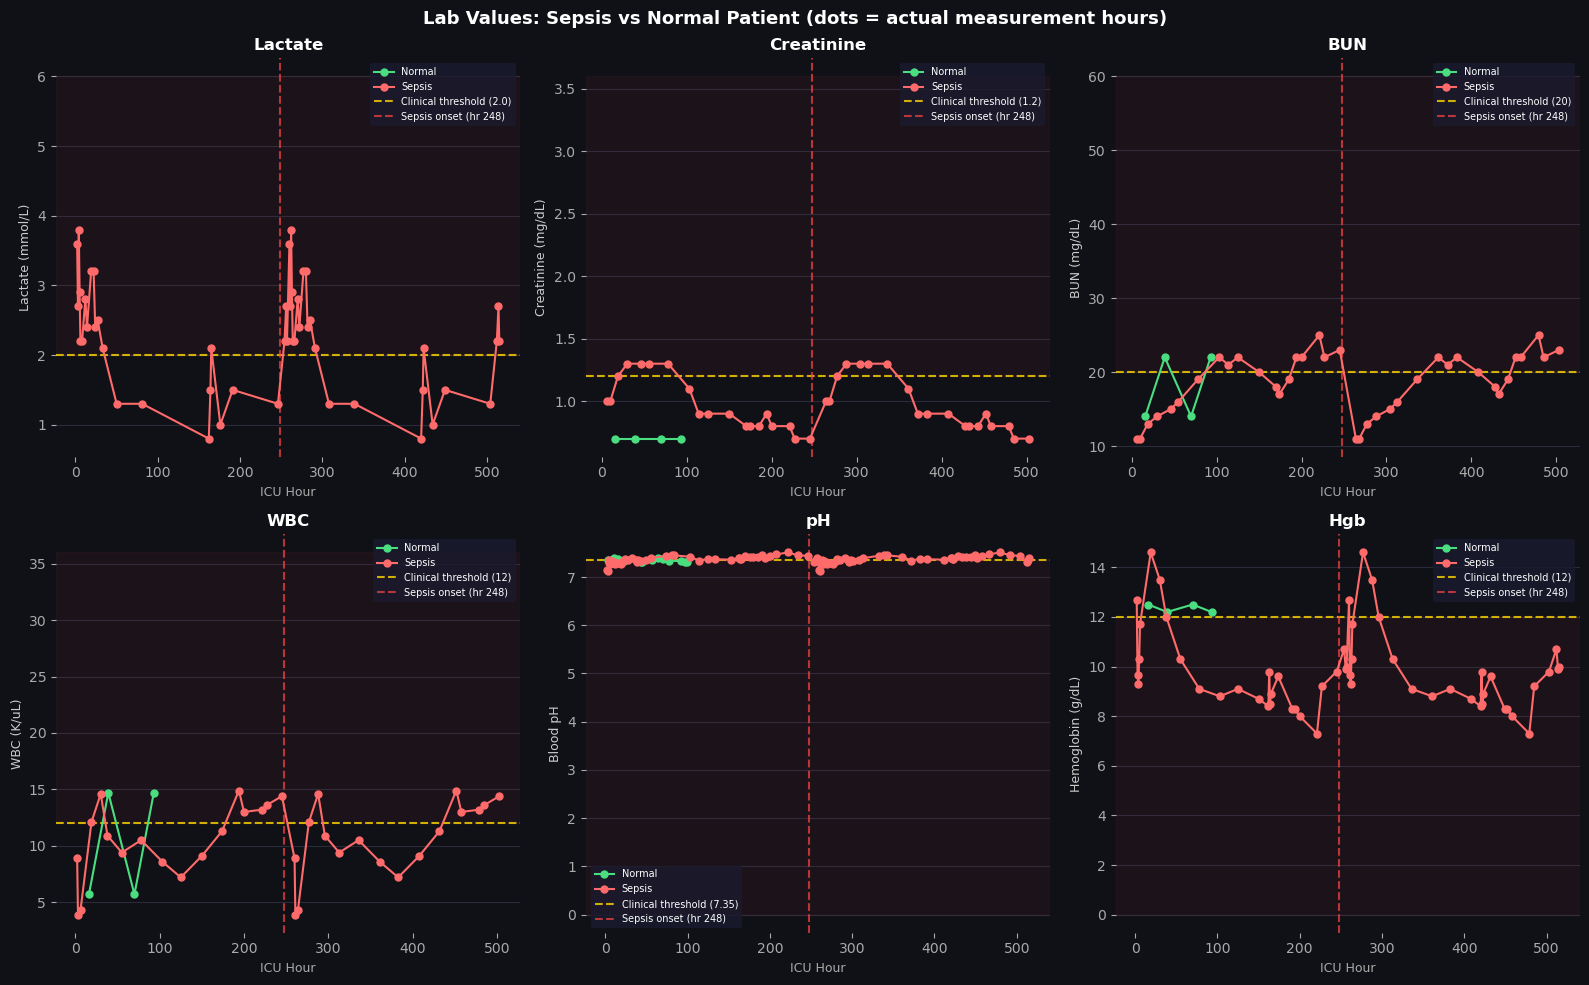

In [6]:
labs = ['Lactate', 'Creatinine', 'BUN', 'WBC', 'pH', 'Hgb']
lab_labels = {
    'Lactate':    'Lactate (mmol/L)',
    'Creatinine': 'Creatinine (mg/dL)',
    'BUN':        'BUN (mg/dL)',
    'WBC':        'WBC (K/uL)',
    'pH':         'Blood pH',
    'Hgb':        'Hemoglobin (g/dL)',
}
# Clinical danger thresholds
thresholds = {
    'Lactate':    2.0,    # >2 = concern
    'Creatinine': 1.2,    # >1.2 = AKI concern
    'BUN':        20,     # >20 = elevated
    'WBC':        12,     # >12 leukocytosis
    'pH':         7.35,   # <7.35 acidosis
    'Hgb':        12,     # <12 anemia
}
threshold_dir = {
    'Lactate': 'above', 'Creatinine': 'above', 'BUN': 'above',
    'WBC': 'above', 'pH': 'below', 'Hgb': 'below'
}

for lab in labs:
    pt_sep[lab] = pd.to_numeric(pt_sep[lab], errors='coerce')
    pt_nor[lab] = pd.to_numeric(pt_nor[lab], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Lab Values: Sepsis vs Normal Patient (dots = actual measurement hours)',
             color='white', fontsize=13, fontweight='bold')

for ax, lab in zip(axes.flatten(), labs):
    ax.set_facecolor('#0F1117')

    # Only plot hours where there's an actual measurement (not NaN)
    sep_valid = pt_sep[pt_sep[lab].notna()]
    nor_valid = pt_nor[pt_nor[lab].notna()]

    ax.plot(nor_valid['hour'], nor_valid[lab], 'o-', color='#4ADE80',
            lw=1.5, ms=5, label='Normal', zorder=3)
    ax.plot(sep_valid['hour'], sep_valid[lab], 'o-', color='#FF6B6B',
            lw=1.5, ms=5, label='Sepsis', zorder=3)

    # Threshold line
    if lab in thresholds:
        thresh = thresholds[lab]
        direction = threshold_dir[lab]
        ax.axhline(thresh, color='#FFD700', lw=1.5, ls='--', alpha=0.8,
                   label=f'Clinical threshold ({thresh})')
        # Shade danger zone
        ylim = ax.get_ylim()
        if direction == 'above':
            ax.axhspan(thresh, thresh * 3, color='#FF4444', alpha=0.05)
        else:
            ax.axhspan(0, thresh, color='#FF4444', alpha=0.05)

    # Sepsis onset
    ax.axvline(sepsis_onset, color='#FF4444', lw=1.5, ls='--',
               alpha=0.7, label=f'Sepsis onset (hr {sepsis_onset})')

    ax.set_title(lab, color='white', fontweight='bold')
    ax.set_ylabel(lab_labels[lab], color='#CCCCCC', fontsize=9)
    ax.set_xlabel('ICU Hour', color='#AAAAAA', fontsize=9)
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.yaxis.grid(True, color='#2A2A3A', lw=0.8)
    ax.set_axisbelow(True)
    ax.legend(facecolor='#1A1A2E', edgecolor='none', labelcolor='white',
              fontsize=7, loc='best')

plt.tight_layout()
plt.show()

## Patient Summary Card

In [7]:
print("=" * 55)
print(f"  PATIENT SUMMARY")
print("=" * 55)

for label, pt, is_septic in [("NORMAL", pt_nor, False), ("SEPSIS", pt_sep, True)]:
    age    = pd.to_numeric(pt['Age'], errors='coerce').iloc[0]
    gender = int(pd.to_numeric(pt['Gender'], errors='coerce').iloc[0])
    gender_str = "Male" if gender == 1 else "Female"
    icu_h  = len(pt)

    print(f"  {label} Patient (ID: {pt['Patient_ID'].iloc[0]})")
    print(f"    Age        : {age:.0f} years")
    print(f"    Gender     : {gender_str}")
    print(f"    ICU Hours  : {icu_h}")
    if is_septic:
        print(f"    Sepsis onset: Hour {sepsis_onset}")
    print()

    for v in ['HR', 'Resp', 'MAP', 'Lactate', 'Creatinine']:
        if v in pt.columns:
            val = pd.to_numeric(pt[v], errors='coerce')
            print(f"    {v:12s}: mean={val.mean():.1f}  min={val.min():.1f}  max={val.max():.1f}")
    print("-" * 55)

  PATIENT SUMMARY
  NORMAL Patient (ID: p000001)
    Age        : 83 years
    Gender     : Female
    ICU Hours  : 108

    HR          : mean=101.6  min=76.0  max=117.0
    Resp        : mean=24.8  min=17.0  max=32.0
    MAP         : mean=87.3  min=44.0  max=141.3
    Lactate     : mean=nan  min=nan  max=nan
    Creatinine  : mean=0.7  min=0.7  max=0.7
-------------------------------------------------------
  SEPSIS Patient (ID: p000009)
    Age        : 28 years
    Gender     : Male
    ICU Hours  : 516
    Sepsis onset: Hour 248

    HR          : mean=112.6  min=85.0  max=143.0
    Resp        : mean=24.2  min=13.0  max=55.5
    MAP         : mean=81.7  min=56.0  max=117.0
    Lactate     : mean=2.2  min=0.8  max=3.8
    Creatinine  : mean=1.0  min=0.7  max=1.3
-------------------------------------------------------
